<a href="https://colab.research.google.com/github/hbaskar/testcolab/blob/main/Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

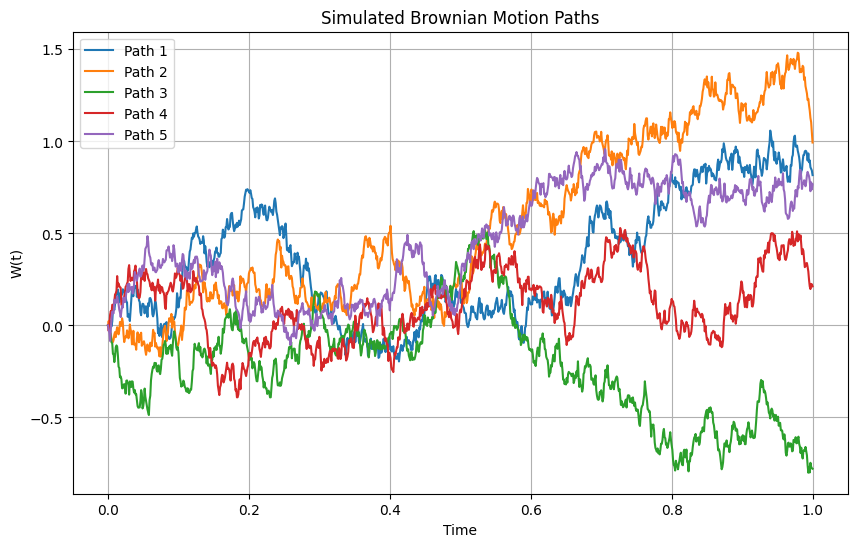

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the simulation
n_steps = 1000  # Number of time steps
n_paths = 5     # Number of independent Brownian motion paths
T = 1.0         # Total time
dt = T / n_steps  # Time step size

# Generate Brownian motion paths
time = np.linspace(0, T, n_steps+1)
paths = np.zeros((n_paths, n_steps+1))

for i in range(n_paths):
    increments = np.sqrt(dt) * np.random.randn(n_steps)
    paths[i, 1:] = np.cumsum(increments)

# Plot the simulated Brownian motion paths
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time, paths[i], label=f"Path {i+1}")
plt.title("Simulated Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.legend()
plt.grid()
plt.show()

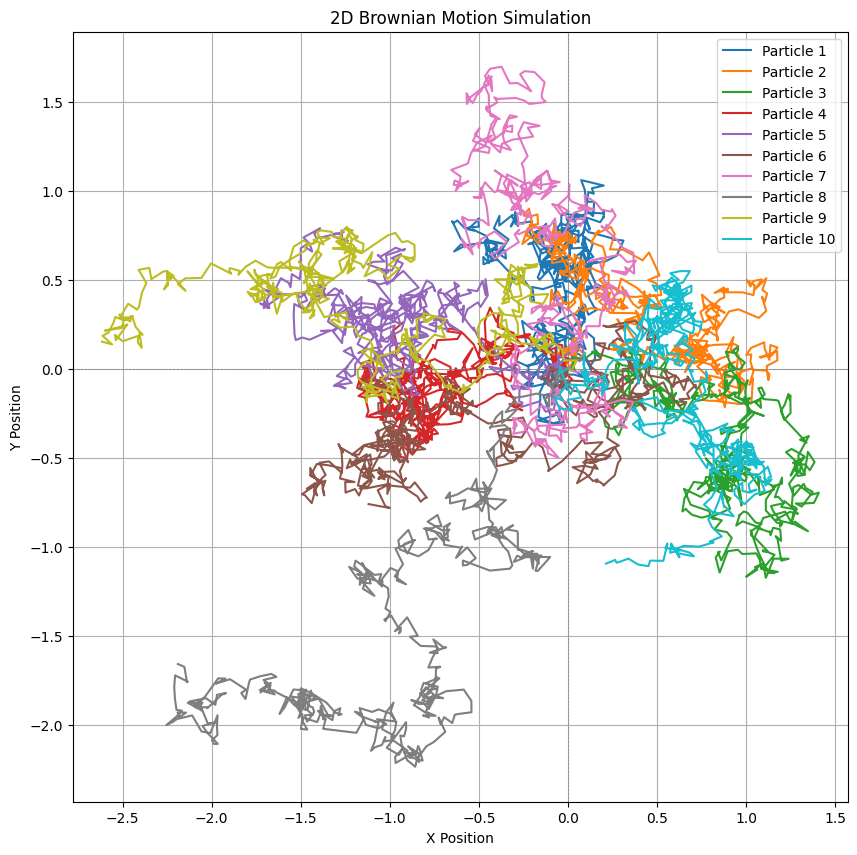

In [ ]:
# Re-import necessary libraries due to the reset environment
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the simulation
n_particles = 100  # Number of particles
n_steps = 500      # Number of time steps
T = 1.0            # Total time
dt = T / n_steps   # Time step size

# Initialize positions of particles
positions = np.zeros((n_particles, 2))  # (x, y) for each particle

# Store all positions for visualization
trajectory = np.zeros((n_steps + 1, n_particles, 2))
trajectory[0] = positions

# Simulate 2D Brownian motion
for step in range(1, n_steps + 1):
    # Random increments for each particle in x and y directions
    increments = np.sqrt(dt) * np.random.randn(n_particles, 2)
    positions += increments
    trajectory[step] = positions

# Plotting the trajectories of a subset of particles
plt.figure(figsize=(10, 10))
for i in range(min(10, n_particles)):  # Plot up to 10 particle trajectories
    plt.plot(trajectory[:, i, 0], trajectory[:, i, 1], label=f"Particle {i+1}")
plt.title("2D Brownian Motion Simulation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
print("Numpy and Matplotlib are installed and ready to use!")

Numpy and Matplotlib are installed and ready to use!


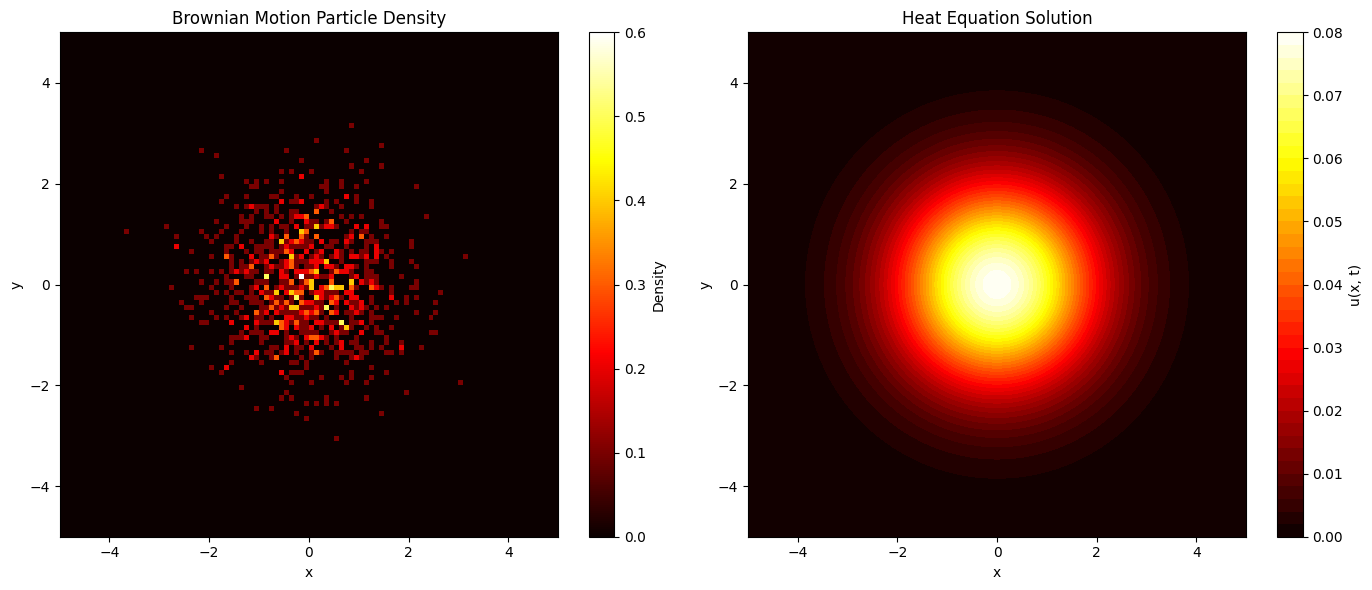

In [ ]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# General parameters
num_particles = 1000  # Number of particles for Brownian motion
num_steps = 100  # Number of time steps
dt = 0.01  # Time step size
t_final = num_steps * dt  # Final time
x_limits = [-5, 5]  # Limits on the x-axis
y_limits = [-5, 5]  # Limits on the y-axis
grid_size = 100  # Grid size for the heat equation
x_range = np.linspace(-5, 5, grid_size)  # Range in x
y_range = np.linspace(-5, 5, grid_size)  # Range in y

# Function for the heat equation solution in 2D
def heat_solution(x, t, grid_x, grid_y):
    d = 2  # Dimension
    coeff = 1 / ((4 * np.pi * t) ** (d / 2))
    return coeff * np.exp(-(grid_x - x[0])**2 / (4 * t) - (grid_y - x[1])**2 / (4 * t))

# Create the grid for the heat equation
grid_x, grid_y = np.meshgrid(x_range, y_range)

# Initialize particle positions for Brownian motion
positions = np.zeros((num_particles, 2))  # All start at (0, 0)

# Record trajectories
trajectory = np.zeros((num_steps, num_particles, 2))
trajectory[0] = positions

# Simulate Brownian motion
for t in range(1, num_steps):
    dW = np.sqrt(dt) * np.random.randn(num_particles, 2)  # Brownian increments
    positions += dW
    trajectory[t] = positions

# Compute the heat equation solution
x_initial = np.array([0, 0])  # Initial point (0, 0)
heat_u = heat_solution(x_initial, t_final, grid_x, grid_y)

# Plot the Brownian particle density and heat equation solution
plt.figure(figsize=(14, 6))

# Brownian motion particle density
plt.subplot(1, 2, 1)
plt.hist2d(trajectory[-1, :, 0], trajectory[-1, :, 1], bins=100, range=[x_limits, y_limits], density=True, cmap='hot')
plt.colorbar(label='Density')
plt.title('Brownian Motion Particle Density')
plt.xlabel('x')
plt.ylabel('y')

# Heat equation solution
plt.subplot(1, 2, 2)
plt.contourf(grid_x, grid_y, heat_u, levels=50, cmap='hot')
plt.colorbar(label='u(x, t)')
plt.title('Heat Equation Solution')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

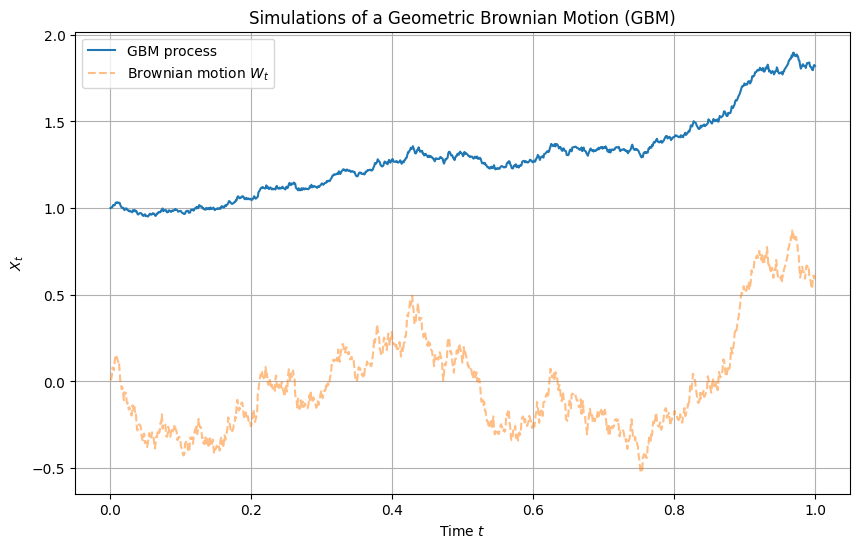

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the Ito process
T = 1.0  # Total time
N = 1000  # Number of time steps
dt = T / N  # Time step
mu = 0.5  # Drift coefficient
sigma = 0.2  # Diffusion coefficient
X0 = 1.0  # Initial value

# Time grid
t = np.linspace(0, T, N)

# Simulating the Wiener process (Brownian motion)
np.random.seed(42)  # For reproducibility
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)

# Simulating the Ito process
X = np.zeros(N)
X[0] = X0
for i in range(1, N):
    X[i] = X[i-1] + mu * X[i-1] * dt + sigma * X[i-1] * dW[i-1]

# Plotting the Ito process
plt.figure(figsize=(10, 6))
plt.plot(t, X, label="GBM process")
plt.plot(t, W, label="Brownian motion $W_t$", alpha=0.5, linestyle='--')
plt.title("Simulations of a Geometric Brownian Motion (GBM)")
plt.xlabel("Time $t$")
plt.ylabel("$X_t$")
plt.legend()
plt.grid()
plt.show()


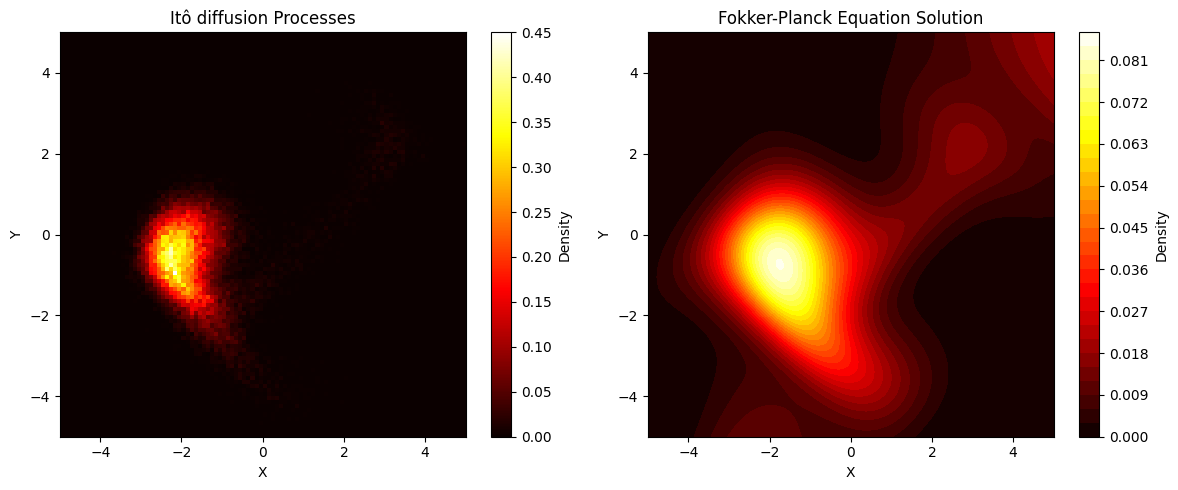

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la simulación
T = 3.0  # Tiempo total
N_time = 500  # Número de pasos de tiempo
dt = T / N_time  # Paso temporal
N_samples = 40000  # Número de partículas simuladas
N_space = 120  # Resolución espacial
x_min, x_max = -5, 5  # Rango espacial en X e Y
dx = (x_max - x_min) / N_space  # Paso en el espacio
x_grid = np.linspace(x_min, x_max, N_space)  # Discretización en X
y_grid = np.linspace(x_min, x_max, N_space)  # Discretización en Y
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)  # Malla espacial en 2D

# Definición de la deriva asimétrica y difusión variable
def b_x(x, y):
    return -0.3 * x + 1.5 * np.sin(y)  # Termino sinusoidal para variabilidad

def b_y(x, y):
    return -0.3 * y - 1.5 * np.cos(x)  # Campo de deriva inclinado

def sigma_x(x, y):
    return 0.3 + 0.2 * np.abs(np.sin(x))  # Difusión variable en X

def sigma_y(x, y):
    return 0.3 + 0.2 * np.abs(np.cos(y))  # Difusión variable en Y

# Simulación del proceso de difusión en 2D con método de Euler-Maruyama
np.random.seed(42)
X = np.zeros((N_samples, N_time + 1))
Y = np.zeros((N_samples, N_time + 1))
X[:, 0] = np.random.normal(0, 0.6, N_samples)  # Condición inicial dispersa
Y[:, 0] = np.random.normal(0, 0.6, N_samples)

for t in range(1, N_time + 1):
    dW_x = np.sqrt(dt) * np.random.randn(N_samples)
    dW_y = np.sqrt(dt) * np.random.randn(N_samples)
    X[:, t] = X[:, t - 1] + b_x(X[:, t - 1], Y[:, t - 1]) * dt + sigma_x(X[:, t - 1], Y[:, t - 1]) * dW_x
    Y[:, t] = Y[:, t - 1] + b_y(X[:, t - 1], Y[:, t - 1]) * dt + sigma_y(X[:, t - 1], Y[:, t - 1]) * dW_y

# Construcción de la ecuación de Fokker-Planck con diferencias finitas
p = np.exp(-((X_grid**2 + Y_grid**2) / 2))  # Condición inicial gaussiana
p /= np.sum(p) * dx * dx  # Normalización de la densidad

p_evolution = np.zeros((N_time + 1, N_space, N_space))
p_evolution[0, :, :] = p

for t in range(1, N_time + 1):
    dp_x = np.gradient(b_x(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=1) / dx
    dp_y = np.gradient(b_y(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=0) / dx
    ddp_x = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=1), axis=1) / dx**2
    ddp_y = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=0), axis=0) / dx**2

    p_evolution[t, :, :] = np.maximum(1e-6, p_evolution[t - 1, :, :] + dt * (-dp_x - dp_y + 0.5 * (ddp_x + ddp_y)))

# Crear gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico del proceso de difusión en 2D
hist2d = axes[0].hist2d(X[:, -1], Y[:, -1], bins=100, range=[[x_min, x_max], [x_min, x_max]], cmap="hot", density=True)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Itô diffusion Processes")
plt.colorbar(hist2d[3], ax=axes[0], label="Density")

# Gráfico de la ecuación de Fokker-Planck en 2D
contour = axes[1].contourf(X_grid, Y_grid, p_evolution[-1, :, :], levels=30, cmap="hot")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Fokker-Planck Equation Solution")
plt.colorbar(contour, ax=axes[1], label="Density")

plt.tight_layout()
plt.show()


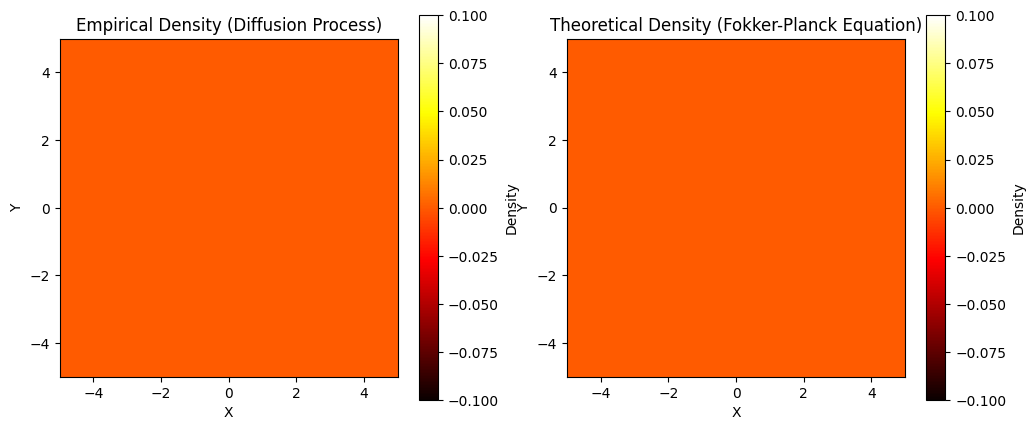

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parámetros de la simulación
T = 3.0  # Tiempo total
N_time = 200  # Pasos de tiempo (reducido para mejorar rendimiento)
dt = T / N_time  # Paso temporal
N_samples = 10000  # Número de partículas simuladas (reducido para eficiencia)
N_space = 100  # Resolución espacial
x_min, x_max = -5, 5  # Rango espacial en X e Y
dx = (x_max - x_min) / N_space  # Paso en el espacio
x_grid = np.linspace(x_min, x_max, N_space)  # Discretización en X
y_grid = np.linspace(x_min, x_max, N_space)  # Discretización en Y
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)  # Malla espacial en 2D

# Definición de la deriva asimétrica y difusión variable
def b_x(x, y):
    return -0.3 * x + 1.5 * np.sin(y)

def b_y(x, y):
    return -0.3 * y - 1.5 * np.cos(x)

def sigma_x(x, y):
    return 0.3 + 0.2 * np.abs(np.sin(x))

def sigma_y(x, y):
    return 0.3 + 0.2 * np.abs(np.cos(y))

# Simulación del proceso de difusión en 2D con método de Euler-Maruyama
np.random.seed(42)
X = np.zeros((N_samples, N_time + 1))
Y = np.zeros((N_samples, N_time + 1))
X[:, 0] = np.random.normal(0, 0.6, N_samples)  # Condición inicial dispersa
Y[:, 0] = np.random.normal(0, 0.6, N_samples)

for t in range(1, N_time + 1):
    dW_x = np.sqrt(dt) * np.random.randn(N_samples)
    dW_y = np.sqrt(dt) * np.random.randn(N_samples)
    X[:, t] = X[:, t - 1] + b_x(X[:, t - 1], Y[:, t - 1]) * dt + sigma_x(X[:, t - 1], Y[:, t - 1]) * dW_x
    Y[:, t] = Y[:, t - 1] + b_y(X[:, t - 1], Y[:, t - 1]) * dt + sigma_y(X[:, t - 1], Y[:, t - 1]) * dW_y

# Construcción de la ecuación de Fokker-Planck con diferencias finitas
p = np.exp(-((X_grid**2 + Y_grid**2) / 2))  # Condición inicial gaussiana
p /= np.sum(p) * dx * dx  # Normalización de la densidad

p_evolution = np.zeros((N_time + 1, N_space, N_space))
p_evolution[0, :, :] = p

for t in range(1, N_time + 1):
    dp_x = np.gradient(b_x(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=1) / dx
    dp_y = np.gradient(b_y(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=0) / dx
    ddp_x = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=1), axis=1) / dx**2
    ddp_y = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=0), axis=0) / dx**2

    p_evolution[t, :, :] = np.maximum(1e-6, p_evolution[t - 1, :, :] + dt * (-dp_x - dp_y + 0.5 * (ddp_x + ddp_y)))

# Crear la figura y los ejes para la animación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inicializar gráficos vacíos
hist2d = axes[0].imshow(np.zeros((N_space, N_space)), extent=[x_min, x_max, x_min, x_max], cmap="hot", origin="lower")
contour = axes[1].imshow(np.zeros((N_space, N_space)), extent=[x_min, x_max, x_min, x_max], cmap="hot", origin="lower")

# Etiquetas y títulos
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Empirical Density (Diffusion Process)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Theoretical Density (Fokker-Planck Equation)")

# Barras de color
cbar1 = plt.colorbar(hist2d, ax=axes[0], label="Density")
cbar2 = plt.colorbar(contour, ax=axes[1], label="Density")

# Función de actualización para la animación
def update(frame):
    # Actualizar la densidad empírica
    hist_data, _, _ = np.histogram2d(X[:, frame], Y[:, frame], bins=N_space, range=[[x_min, x_max], [x_min, x_max]], density=True)
    hist2d.set_data(hist_data.T)

    # Actualizar la solución de Fokker-Planck
    contour.set_data(p_evolution[frame, :, :])

    return hist2d, contour

# Crear la animación
ani = animation.FuncAnimation(fig, update, frames=N_time, interval=30)

# Mostrar la animación en pantalla
plt.show()

ani.save("diffusion_fokkerplanck.mp4", writer="ffmpeg", fps=30)


In [ ]:
import os
print(os.getcwd())  # Esto muestra el directorio donde se guardó el archivo


/content


Video guardado como 'diffusion_fokkerplanck.mp4'.


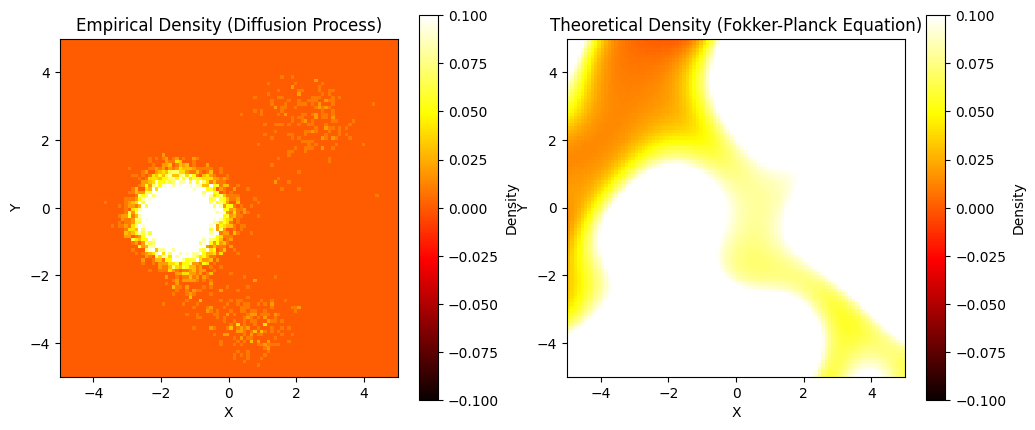

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors as mcolors

# Parámetros de la simulación
T = 10.0  # Tiempo total aumentado
N_time = 600  # Más pasos de tiempo para mayor duración
dt = T / N_time  # Paso temporal
N_samples = 10000  # Número de partículas (ajustado para rendimiento)
N_space = 100  # Resolución espacial
x_min, x_max = -5, 5  # Rango espacial en X e Y
dx = (x_max - x_min) / N_space  # Paso en el espacio
x_grid = np.linspace(x_min, x_max, N_space)  # Discretización en X
y_grid = np.linspace(x_min, x_max, N_space)  # Discretización en Y
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)  # Malla espacial en 2D

# Definición de la deriva asimétrica y difusión variable
def b_x(x, y):
    return -0.3 * x + 1.5 * np.sin(y)

def b_y(x, y):
    return -0.3 * y - 1.5 * np.cos(x)

def sigma_x(x, y):
    return 0.3 + 0.2 * np.abs(np.sin(x))

def sigma_y(x, y):
    return 0.3 + 0.2 * np.abs(np.cos(y))

# Simulación del proceso de difusión en 2D con método de Euler-Maruyama
np.random.seed(42)
X = np.zeros((N_samples, N_time + 1))
Y = np.zeros((N_samples, N_time + 1))
X[:, 0] = np.random.normal(0, 0.6, N_samples)  # Condición inicial dispersa
Y[:, 0] = np.random.normal(0, 0.6, N_samples)

for t in range(1, N_time + 1):
    dW_x = np.sqrt(dt) * np.random.randn(N_samples)
    dW_y = np.sqrt(dt) * np.random.randn(N_samples)
    X[:, t] = X[:, t - 1] + b_x(X[:, t - 1], Y[:, t - 1]) * dt + sigma_x(X[:, t - 1], Y[:, t - 1]) * dW_x
    Y[:, t] = Y[:, t - 1] + b_y(X[:, t - 1], Y[:, t - 1]) * dt + sigma_y(X[:, t - 1], Y[:, t - 1]) * dW_y

# Construcción de la ecuación de Fokker-Planck con diferencias finitas
p = np.exp(-((X_grid**2 + Y_grid**2) / 2))  # Condición inicial gaussiana
p /= np.sum(p) * dx * dx  # Normalización de la densidad

p_evolution = np.zeros((N_time + 1, N_space, N_space))
p_evolution[0, :, :] = p

for t in range(1, N_time + 1):
    dp_x = np.gradient(b_x(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=1) / dx
    dp_y = np.gradient(b_y(X_grid, Y_grid) * p_evolution[t - 1, :, :], axis=0) / dx
    ddp_x = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=1), axis=1) / dx**2
    ddp_y = np.gradient(np.gradient(p_evolution[t - 1, :, :], axis=0), axis=0) / dx**2

    # Evitar valores negativos en la densidad
    p_evolution[t, :, :] = np.maximum(0, p_evolution[t - 1, :, :] + dt * (-dp_x - dp_y + 0.5 * (ddp_x + ddp_y)))

# Crear la figura y los ejes para la animación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normalización para evitar valores negativos en la escala de color
vmin = 0  # Mínimo de la escala en 0
vmax = None  # Dejar que Matplotlib ajuste el máximo

# Inicializar gráficos con escala ajustada
hist2d = axes[0].imshow(np.zeros((N_space, N_space)), extent=[x_min, x_max, x_min, x_max],
                        cmap="hot", origin="lower", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))

contour = axes[1].imshow(np.zeros((N_space, N_space)), extent=[x_min, x_max, x_min, x_max],
                         cmap="hot", origin="lower", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))

# Etiquetas y títulos
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Empirical Density (Diffusion Process)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Theoretical Density (Fokker-Planck Equation)")

# Barras de color
cbar1 = plt.colorbar(hist2d, ax=axes[0], label="Density")
cbar2 = plt.colorbar(contour, ax=axes[1], label="Density")

# Función de actualización para la animación
def update(frame):
    # Actualizar la densidad empírica
    hist_data, _, _ = np.histogram2d(X[:, frame], Y[:, frame], bins=N_space, range=[[x_min, x_max], [x_min, x_max]], density=True)
    hist2d.set_data(hist_data.T)

    # Actualizar la solución de Fokker-Planck
    contour.set_data(p_evolution[frame, :, :])

    return hist2d, contour

# Crear la animación con tiempos más largos
ani = animation.FuncAnimation(fig, update, frames=N_time, interval=50)

# Guardar el video con más fluidez y duración
ani.save("diffusion_fokkerplanck.mp4", writer="ffmpeg", fps=60)

print("Video guardado como 'diffusion_fokkerplanck.mp4'.")

# Mostrar la animación en pantalla
plt.show()
